In [73]:
## Lineer Regresyon ile 2022 Dünya Mutluluk Skoru Tahmini ##
import numpy as np # Matematiksel işlemleri hızlı yapmak için çağırdım.
import pandas as pd # Dosyamı okuması ve tablolaştırması için çağırdım.
import matplotlib.pyplot as plt # Model eğitimi sonrası gerçek ve tahmini sonuçları grafiksel şekilde göstermek için çağırdım.

from sklearn.model_selection import train_test_split # Eğiteceğim ve test edeceğim verileri bölmek için çağırdım.
from sklearn.linear_model import LinearRegression # Lineer regresyon modeli için çağırdım.
from sklearn.metrics import mean_absolute_error # Hata ölçümü yapmak için çağırdım.

In [36]:
# Veri setini okutuyorum ve virgül yüzünden stirng gözüken değerleri floata çeviriyorum.

df_happiness = pd.read_csv("2022.csv", decimal=",")

# Veri setinin ilk 5 satırına bakıyorum.

df_happiness.head()

,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,1,Finland,7.821,7.886,7.756,2.518,1.892,1.258,0.775,0.736,0.109,0.534
1,2,Denmark,7.636,7.710,7.563,2.226,1.953,1.243,0.777,0.719,0.188,0.532
2,3,Iceland,7.557,7.651,7.464,2.320,1.936,1.320,0.803,0.718,0.270,0.191
3,4,Switzerland,7.512,7.586,7.437,2.153,2.026,1.226,0.822,0.677,0.147,0.461
4,5,Netherlands,7.415,7.471,7.359,2.137,1.945,1.206,0.787,0.651,0.271,0.419


**Veri seti: world_happiness_report_2022.csv**

 **Economy(GDP per Capita):** Kişi başına düşen milli gelir

 **Explained by: Social support:** Sosyal destek

 **Explained by: Healthy life expectancy:** Sağlıklı yaşam beklentisi

**Explained by: Freedom to make life choices:** Karar verme özgürlüğü

 **Happiness Score:** Mutluluk puanı

**Amaç:** Economy, social support, health, freedom gibi özelliklerin Happiness Score'u etkileyip etkilemediğine bakmak ve happiness score tahmini yapıp gerçek sonuçla karşılaştırmak.

In [80]:
# Eğitim ve test için özellikleri seçip ayırıyorum.
# İşimin kolaylaşması için sütun başlıklarının isimlerini kolaylaştırıyorum.
df_happiness = df_happiness.rename(columns={
    "Explained by: GDP per capita": "economy",
    "Explained by: Social support": "social_support",
    "Explained by: Healthy life expectancy": "health",
    "Explained by: Freedom to make life choices":"freedom",
    "Happiness score": "happiness_score"
})

# X ve y'yi tanımlayıp ilk 5 değerine bakıyorum
X= df_happiness[["economy","social_support","health","freedom"]]
y= df_happiness['happiness_score']

# Veri setinde NaN bölümleri .dropna() ile çıkardım.
X.dropna(inplace=True)
y.dropna(inplace=True)

print(X.head())
print(f"\n{y.head()}")

   economy  social_support  health  freedom
0    1.892           1.258   0.775    0.736
1    1.953           1.243   0.777    0.719
2    1.936           1.320   0.803    0.718
3    2.026           1.226   0.822    0.677
4    1.945           1.206   0.787    0.651

0    7.821
1    7.636
2    7.557
3    7.512
4    7.415
Name: happiness_score, dtype: float64


/tmp/ipython-input-3352583922.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


In [56]:
# Eğitim ve test için veriyi bölüyorum sonradan kontrol amaçlı bölünmüş verilerin büyüklüğüne bakıyorum.
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2, # Buradaki oran verinin ne kadarının teste ayrıldığını gösteriyor(%80 train, %20 test olarak seçtik).
    random_state=42
)

print(X_train.shape, y_train.shape)
print()
print(X_test.shape, y_test.shape)

(116, 4) (116,)

(30, 4) (30,)


In [57]:
# Lineer regresyon ile modeli eğitiyorum.

lin_model= LinearRegression()

lin_model.fit(X_train, y_train) # .fit ile makineye verileri öğretiyorum.

LinearRegression()

In [72]:
# Makineye tahmin yaptırıp bunları gerçek değerleriyle karşılaştırmak için hem gerçek hem tahmin değerlerinin ilk 10'unu yazdırıyorum.
y_pred= lin_model.predict(X_test)

print("İlk 5 tahmin edilen puan:")
print(y_pred[:5])
print()
print("İlk 5 gerçek puan değeri:")
print(y_test.values[:5])

İlk 5 tahmin edilen puan:
[5.84373614 5.68465852 6.12612688 6.63576844 6.0205958 ]

İlk 5 gerçek puan değeri:
[6.128 5.084 6.477 6.687 6.178]


In [59]:
# Ortalama mutlak hata (mean absolute error) ile makinemin modelde ortalama hatasına bakıyorum.
# Düzenli gözükmesi için ondalıklı kısımdan 2 basamak gösteriyorum.
mae= mean_absolute_error(y_test, y_pred)

print(f"Modelim tahminlerinde ortalama {mae:.2} puan yanılıyor.")

# Modelimin doğruluk(Accuracy) değerini yüzdelik halinde göstermek için;
# R2 skorunu hesapladım.
# R2 skorunu yüzdelik şekilde gösterip ondalıklı kısmından 2 basamak gösterdim.

r2 = lin_model.score(X_test, y_test)

r2_percent = r2*100

print(f"Model doğruluğu: %{r2_percent:.2f}")

Modelim tahminlerinde ortalama 0.44 puan yanılıyor.
Model doğruluğu: %68.72


In [67]:
# Orijinal veri setini bozmamak için kopyasını alıyorum.
# Gerçek ve tahmini puanları tabloya ekliyorum

result_reg= X_test.copy()

result_reg["Mutluluk Puanı(Gerçek)"] = y_test.values
result_reg["Mutluluk Puanı(Tahmini)"] = y_pred

In [61]:
# Son olarak karşılaştırma tablomun ilk 10 satırını yazdırıyorum

print("Mutluluk Skoru Tablosu (Gerçek vs Tahmini)")
print()
print(result_reg.head(10))

Mutluluk Skoru Tablosu (Gerçek vs Tahmini)

     economy  social_support  health  freedom  Mutluluk Puanı(Gerçek)  \
45     1.552           0.886   0.623    0.621                   6.128   
97     1.411           1.081   0.583    0.473                   5.084   
27     1.719           1.006   0.655    0.605                   6.477   
19     1.863           1.219   0.808    0.567                   6.687   
42     1.550           1.086   0.658    0.546                   6.178   
120    1.049           0.413   0.374    0.448                   4.516   
29     1.615           1.180   0.672    0.665                   6.474   
80     1.957           0.954   0.942    0.400                   5.425   
66     1.468           1.068   0.665    0.448                   5.768   
18     1.907           1.106   0.764    0.492                   6.805   

     Mutluluk Puanı(Tahmini)  
45                  5.843736  
97                  5.684659  
27                  6.126127  
19                  6.635768

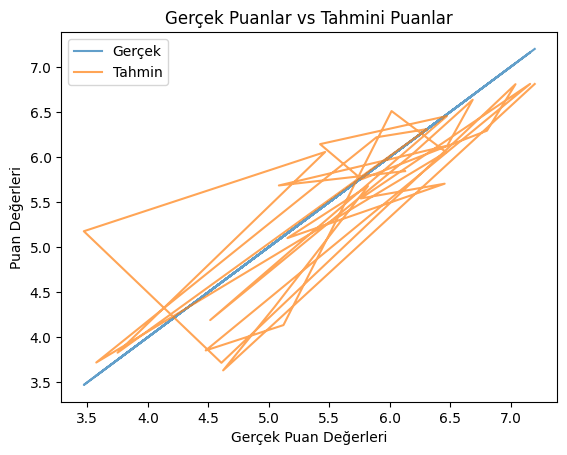

In [86]:
# Burada da modelimi grafiğe dökmek istediğim için matplotlib kütüphanesini kullandım.
plt.figure()
plt.plot(y_test, y_test, label="Gerçek", alpha=0.7)
plt.plot(y_test, y_pred, label="Tahmin", alpha=0.7)

plt.xlabel("Gerçek Puan Değerleri")
plt.ylabel("Puan Değerleri")
plt.title("Gerçek Puanlar vs Tahmini Puanlar")
plt.legend()
plt.show()

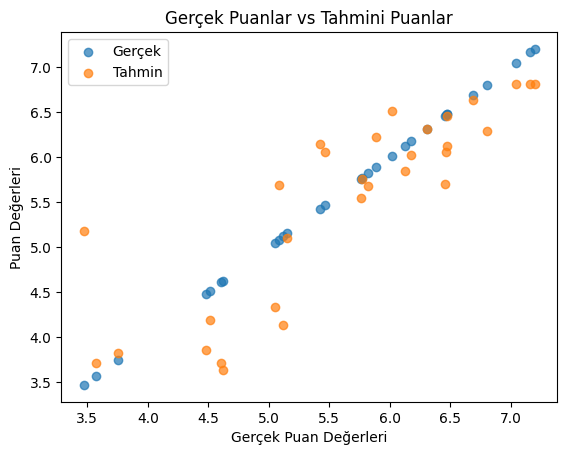

In [88]:
# .plot methodu ile grafik çok düzensiz durduğu için .scatter methodunu kullandım.
plt.figure()
plt.scatter(y_test, y_test, label="Gerçek", alpha=0.7)
plt.scatter(y_test, y_pred, label="Tahmin", alpha=0.7)

plt.xlabel("Gerçek Puan Değerleri")
plt.ylabel("Puan Değerleri")
plt.title("Gerçek Puanlar vs Tahmini Puanlar")
plt.legend()
plt.show()